In [ ]:
""""
    Esses que estão na raiz da pasta (*.txt) estão com o intervalo de tempo igual e sem offset.
    Deixei um "read_me" que descreve as condições de testes e descreve cada arquivo.

    O primeiro é a medição mais longa que foi feita para aquecer o motor. Talvez, dê para comparar um bloco inicial do final para ver se a temperatura altera as características vibratórias do eixo.

    Pensamos em avaliar três situações nesta primeira etapa:
    1) Avaliar qual seria uma janela de corte aceitável (com o motor trabalhando em regime), de forma a não termos diferenças estatísticas nos dados analisados (comparar janelas de 1s, 5s, 10s, por exemplo).
    2) Avaliar diferenças estatísticas ao longo do período de medição da PTO (justamente para avaliar a influência do aquecimento, etc). 
    3) Comparar estatisticamente valores obtidos em diferentes pontos de medição. Verificar se é possível diferenciar claramente o comportamento vibratór…

    Tarefa inicial, com o arquivo Medicao01_PTO.txt.
    1) Abrir dados e verificar gráficos de aceleração nos 3 eixos em função do tempo.
    2) Pegar um intervalo de tempo onde o motor, a princípio, esteja trabalhando em regime (acredito que mais do meio para o final).
    3) Extrair e comparar dados estatísticos (domínio tempo e frequência) para diferentes janelas temporais. Começar analisando uma janela maior, depois ir reduzindo para comparar os resultados.
"""

In [2]:
#Começaremos com a Importação das nossas Bibliotecas

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.weightstats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (24, 24)

ModuleNotFoundError: No module named 'statsmodels'

In [2]:
#Extrairemos os Dados, adicionaremos Titulos e colocaremos em um DataFrame

df_cnh_pto = pd.read_csv('Medicao01_PTO.txt', sep=r'\s+', header=None)
df_cnh_pto.columns = ['Time [s]', 'Acceleration X [g]', 'Acceleration Y [g]', 'Acceleration Z [g]']
df_cnh_pto.to_csv('Medicao01_PTO_titulado.txt', sep=' ', index=False)

df_cnh_pto.head(10).style.hide(axis='index')

Time [s],Acceleration X [g],Acceleration Y [g],Acceleration Z [g]
0.000000,-0.012780,-0.008438,0.003294
0.001000,-0.008480,-0.002438,0.019594
0.002000,-0.009980,-0.000438,0.028194
0.003000,-0.011780,0.006562,0.014694
0.004000,-0.005280,0.003562,0.022794
0.005000,-0.004580,-0.008438,0.021894
0.006000,-0.009880,-0.005438,0.022094
0.007000,-0.010980,0.000562,0.028394
0.008000,-0.004680,0.000562,0.021894
0.009000,-0.000480,-0.004438,0.006594


In [3]:
#Faremos agora a sua Analise Estatistica (.info)(.describe)

df_cnh_pto.info()
df_cnh_pto.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950040 entries, 0 to 950039
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Time [s]            950040 non-null  float64
 1   Acceleration X [g]  950040 non-null  float64
 2   Acceleration Y [g]  950040 non-null  float64
 3   Acceleration Z [g]  950040 non-null  float64
dtypes: float64(4)
memory usage: 29.0 MB


,Time [s],Acceleration X [g],Acceleration Y [g],Acceleration Z [g]
count,950040.000000,9.500400e+05,9.500400e+05,9.500400e+05
mean,475.019500,7.325163e-10,-9.644299e-10,1.038487e-10
std,274.253069,4.559825e-01,4.801431e-01,1.916370e-01
min,0.000000,-1.766080e+00,-2.590438e+00,-1.268606e+00
25%,237.509750,-2.434204e-01,-3.184384e-01,-1.077062e-01
50%,475.019500,-1.380401e-03,-5.438399e-03,1.009379e-02
75%,712.529250,2.585196e-01,2.295616e-01,1.126938e-01
max,950.039000,1.804920e+00,2.655562e+00,2.324394e+00


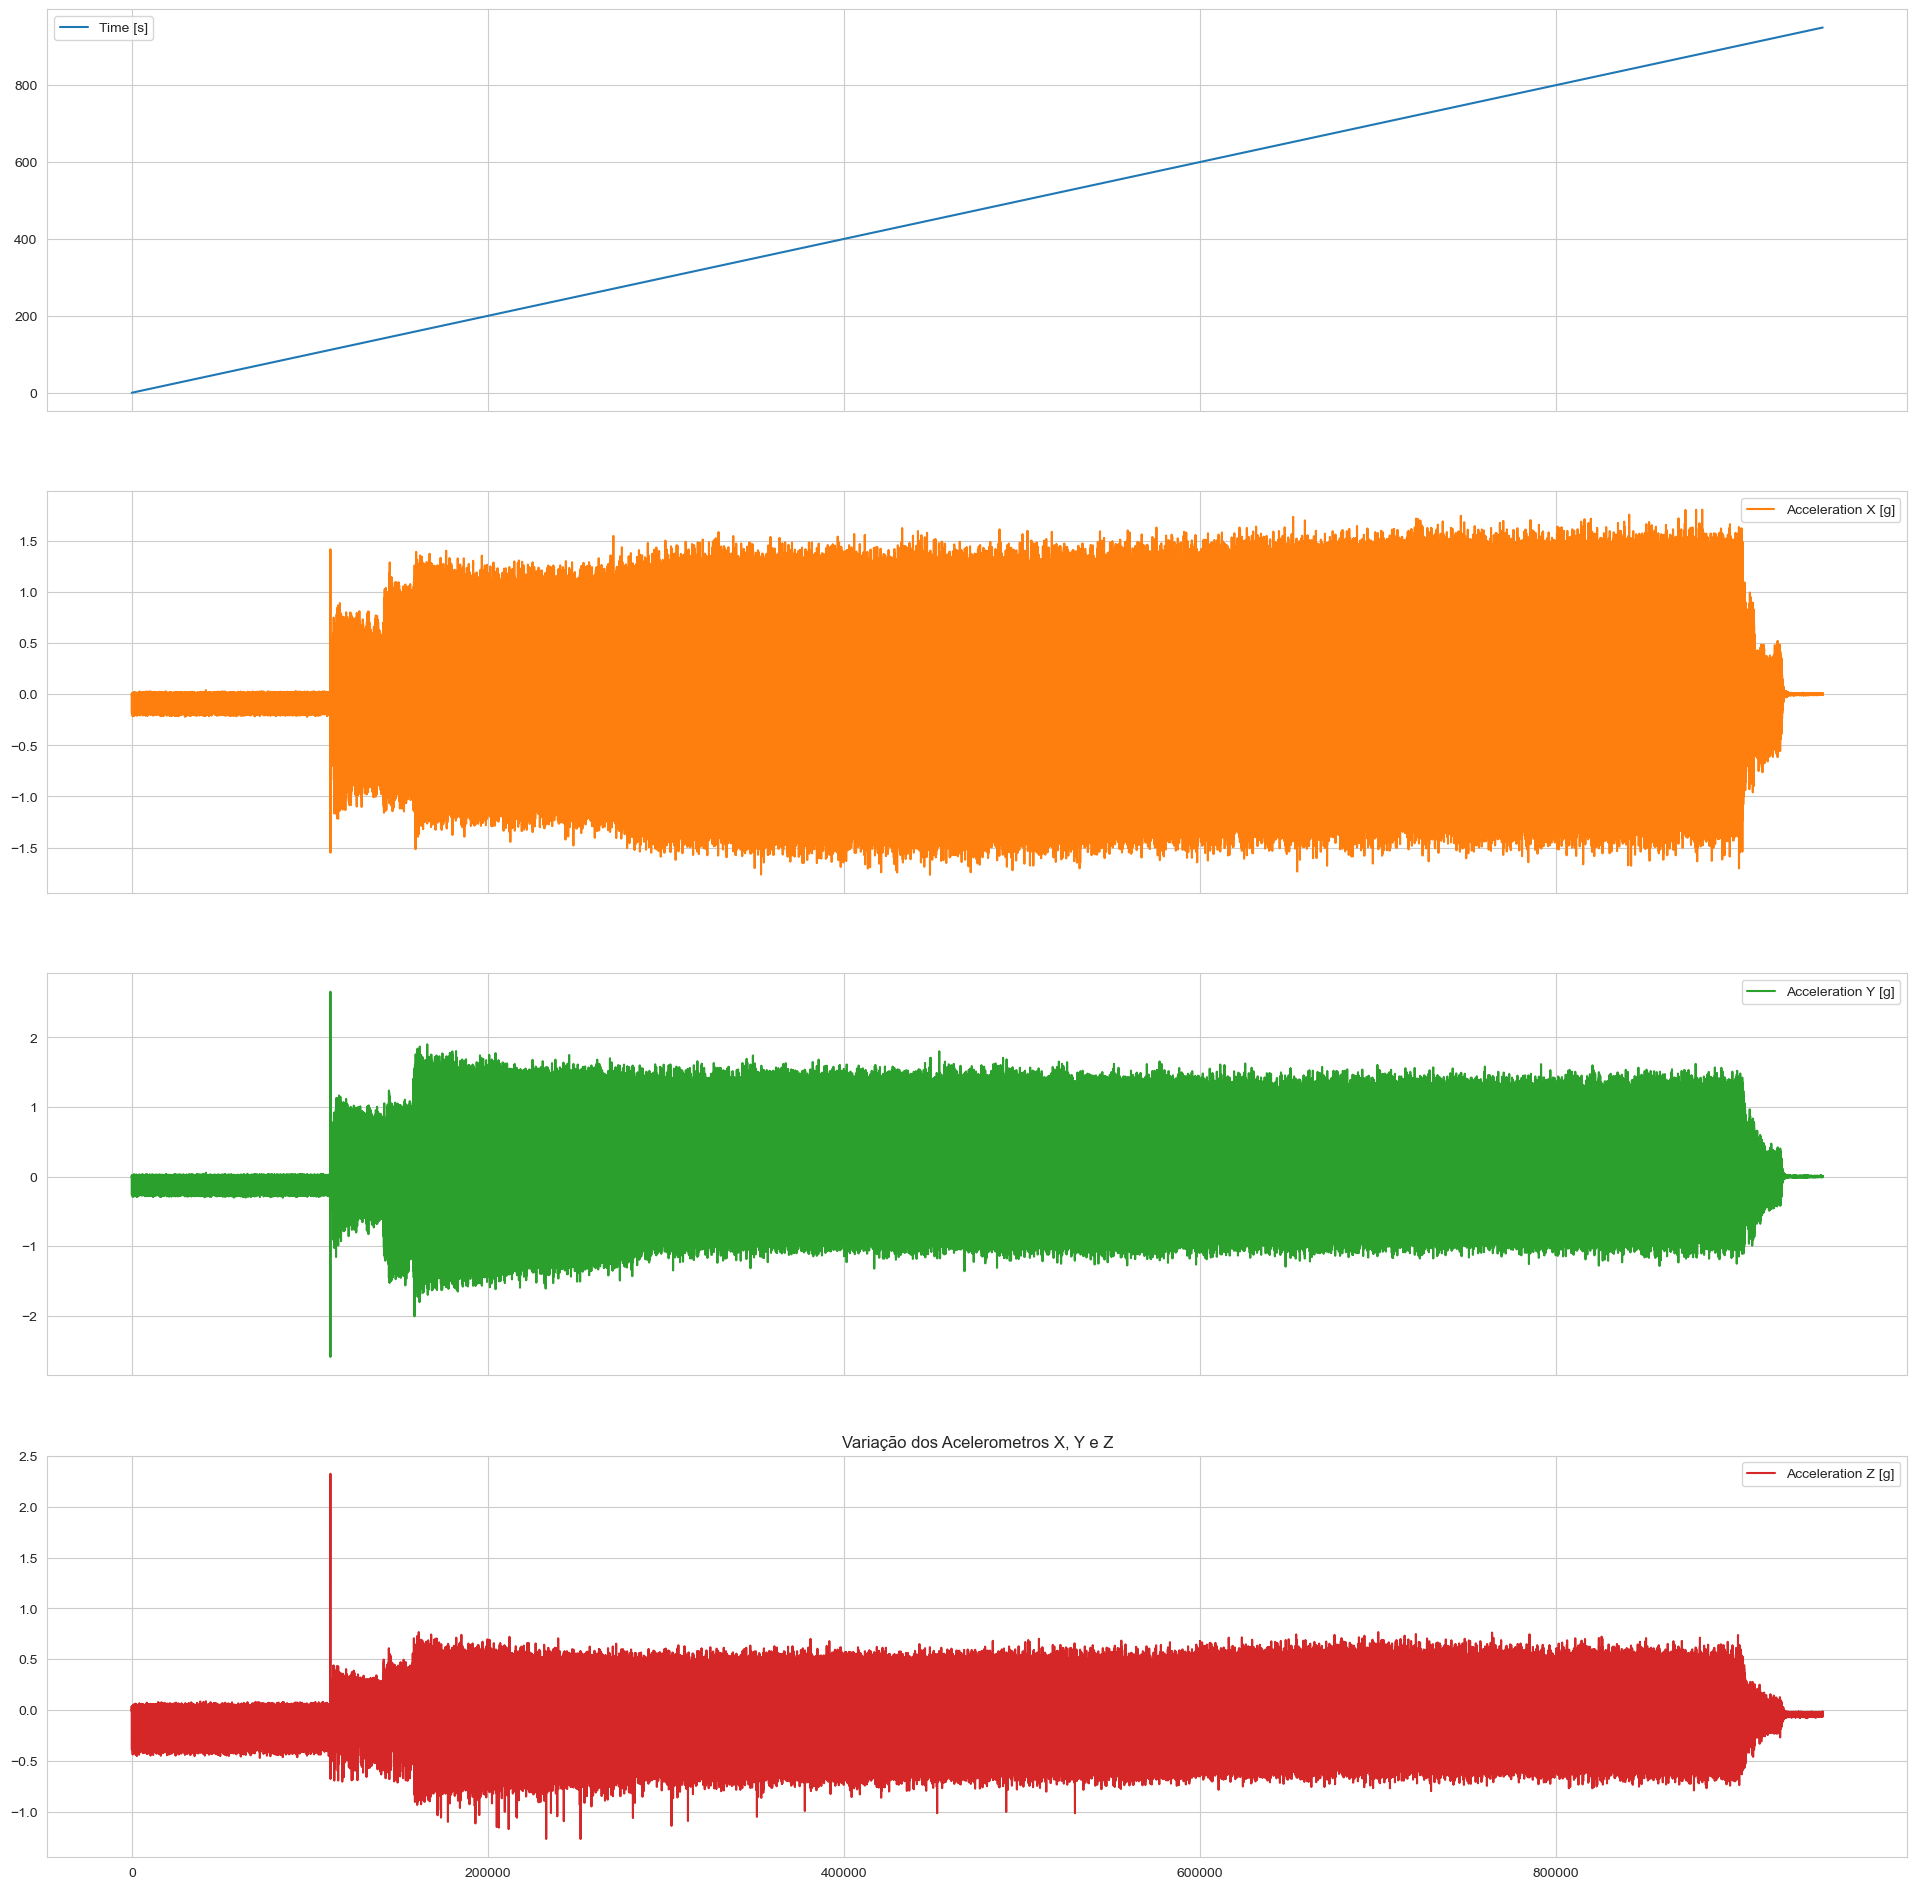

In [4]:
#Concluida sua Verificaçao, faremos o Plot como Funçao dos Registros

df_cnh_pto.plot(subplots = True)
plt.title('Variação dos Acelerometros X, Y e Z')
plt.show()

In [ ]:
"""
   Antes de prosseguir, seria interessante pontuar algumas observaçoes:

   1) Perto do t = 100s, temos um grande pico na vibraçao do sistema (muito provavelmente a maquina fora ligada);
     1.1) Supondo que sim, fora ligada a maquina, podemos confirmar uma quantidade consideravel de ruido extra provocado pelo mesmo (sensorear em outras partes? outro sensor? fixaçao?);
     1.2) A vibraçao no final e muito menor que a inicial (por que? seria a maquina ja desligada, mas se no inicio tambem estava?)
   2) Apesar de estar inicialmente 'fria', os valores nao diferem muito do restante, chegando a estabilidade em cerca de 200s apos o acionamento (referente ao pico repentino);
     2.1) Pode implicar que a partir de 4 minutos de funcionamento ja poderemos extrair as variaveis e os dados para o modelo;
   3) Vibraçoes mais reduzidas em Z, enquanto X e Y mantem-se num intervalo parecido 
     3.1) Diferentemente de Y e Z, a aceleraçao em X acaba por aumentar ligeiramente ao inves de diminuir (posicionamento do sensor?)
   4) Como mencionado no "Read Me", precisamos verificar a orientaçao dos sensores para garantir o sentido correto (verificar na reuniao)
"""

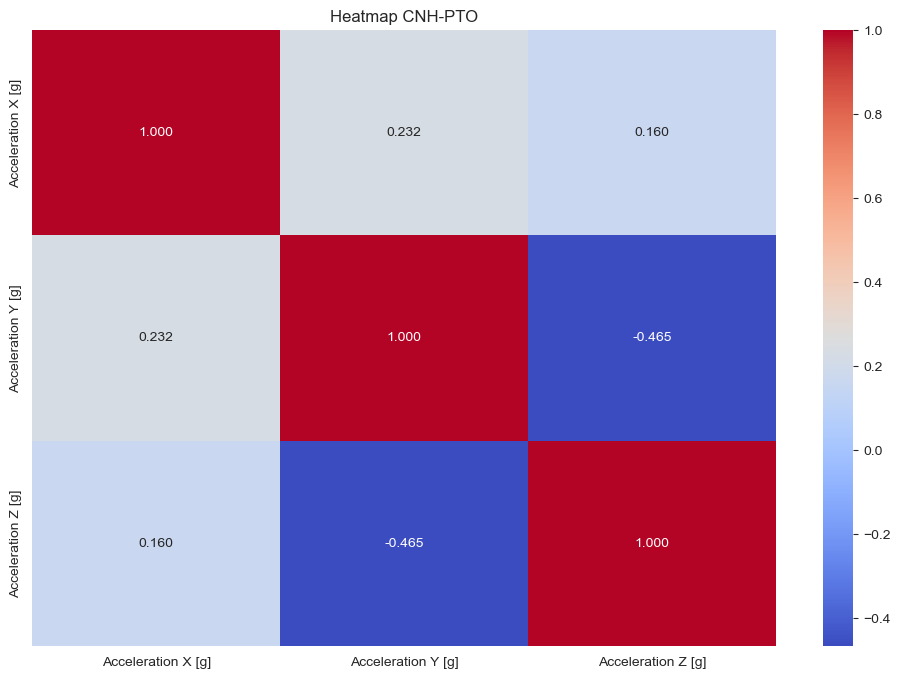

In [5]:
#Para verificar mais Correlaçoes Matematicas, usaremos o HeatMap

correlacoes = df_cnh_pto.drop(columns=['Time [s]']).corr()

plt.figure(figsize = (12, 8))
sns.heatmap(correlacoes, annot = True, cmap = 'coolwarm', fmt = '.3f')
plt.title('Heatmap CNH-PTO')
plt.show()

In [ ]:
"""
   Feita a analise inicial pelo dominio do Tempo [s], faremos agora no dominio da Frequencia [Hz].

   Segundo o recomendado para o Tempo: 
    - Peak Value*: O maior impacto ou choque registrado no teste.
    - Valor RMS: Mede a energia média contínua da vibração. 
    - Crest Factor [Pico / RMS]: Indica se o sinal é composto por impactos repentinos ou por uma vibração contínua.

   Segundo o recomendado para a Frequencia: 
    - Frequências de Ressonância*: Identificar em quais frequências a amplitude "explode", se a frequência de rotação da  máquina coincidir com essas montanhas, a estrutura vai vibrar até quebrar.
    - Frequência Fundamental [RPM]: Identificar o pico correspondente à rotação do motor/eixo. Se ele estiver muito alto, indica desbalanceamento mecânico.
    - Harmônicos [2*RPM / 3*RPM]: Geralmente indicam desalinhamento de eixos ou folgas mecânicas.
"""

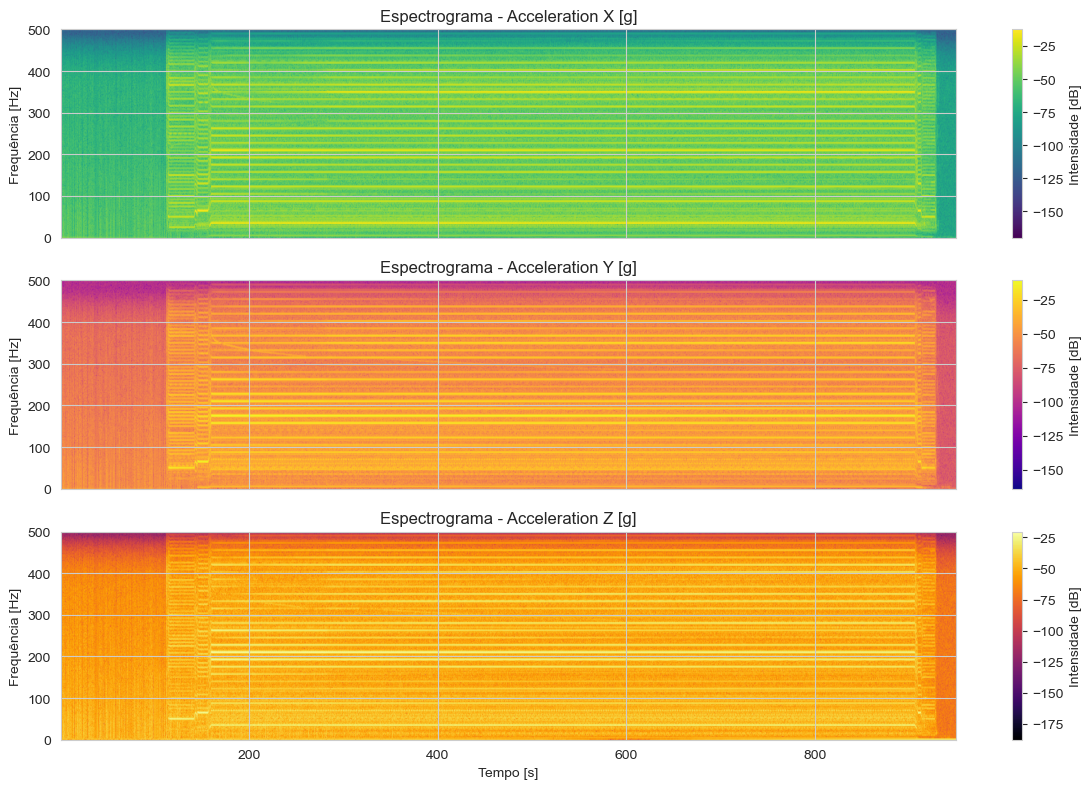

In [11]:
#Faremos um Spectograma para ver as diferentes Frequencias ao longo do Tempo

Frequencia = 1000  

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
eixos = ['Acceleration X [g]', 'Acceleration Y [g]', 'Acceleration Z [g]']
cores = ['viridis', 'plasma', 'inferno']

for i, eixo in enumerate(eixos):
    pxx, freqs, bins, im = axs[i].specgram(df_cnh_pto[eixo], NFFT=512, Fs=Frequencia, noverlap=128, cmap=cores[i])
    axs[i].set_title(f'Espectrograma - {eixo}')
    axs[i].set_ylabel('Frequência [Hz]')
    fig.colorbar(im, ax=axs[i], label='Intensidade [dB]')

axs[-1].set_xlabel('Tempo [s]')
plt.tight_layout()
plt.show()

In [ ]:
"""
    Conforme a temperatura vai aumentando (0-120s pos ligarem), podemos ver uma queda continua em uma das Frequencias, a qual sai de ~380 para ~320 (seria o que? influencia em algo a mais?).

    Realizaremos uma Fast Fourrier Transformation (FFT) para visualizar os picos da Amplitude do sensor.
"""

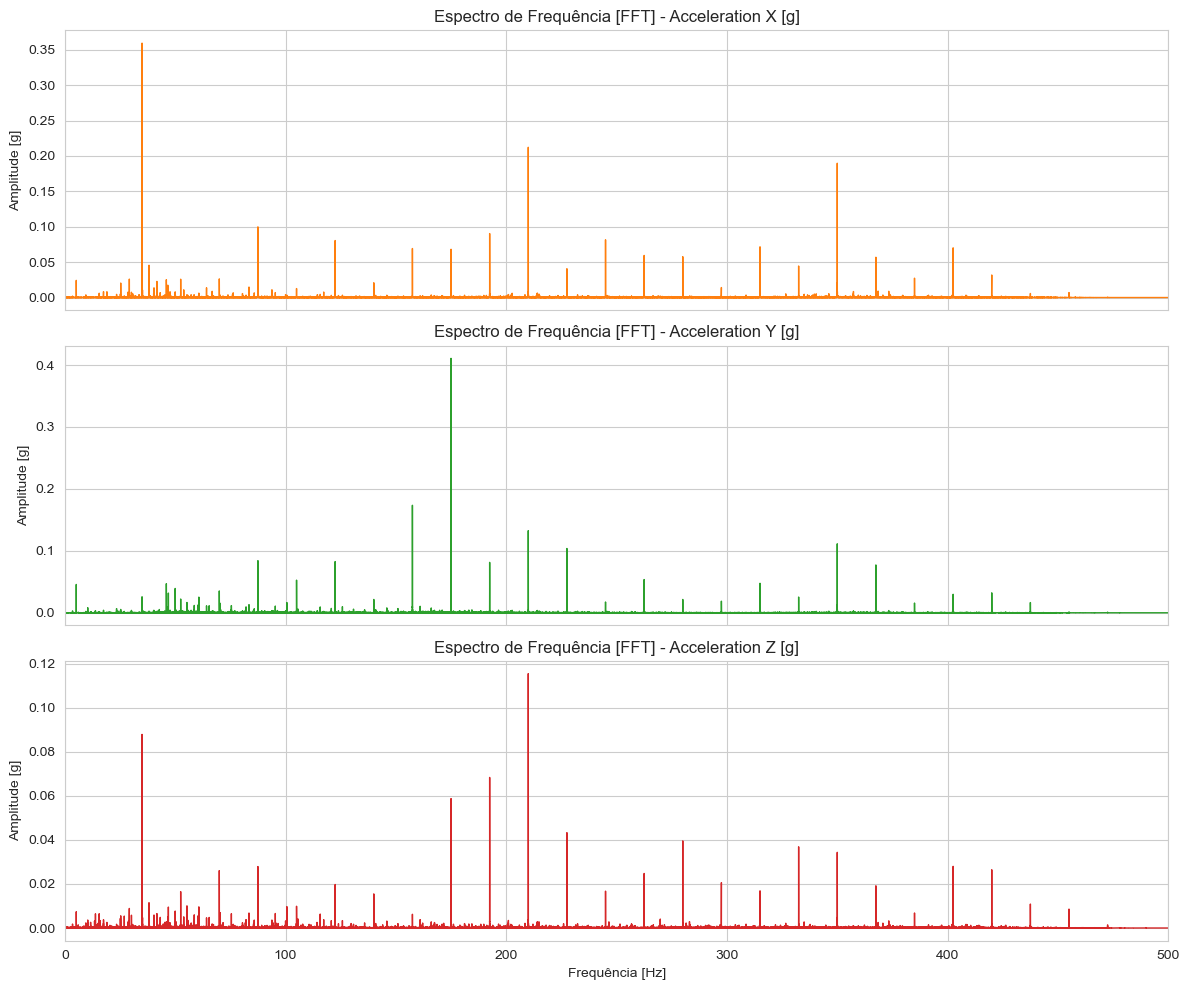

In [20]:
#Começaremos com uma Filtragem dos dados - Operaçao (200s a 800s)
dados_ativos = df_cnh_pto[(df_cnh_pto['Time [s]'] >= 200) & (df_cnh_pto['Time [s]'] <= 800)]

Frequencia = 1000  
N = len(dados_ativos)  

#Criaremos agora o Vetor de Frequências "(metade positiva do espectro - Nyquist)"
xf = np.fft.fftfreq(N, 1/Frequencia)[:N//2]

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
eixos = ['Acceleration X [g]', 'Acceleration Y [g]', 'Acceleration Z [g]']
cores = ['#ff7f0e', '#2ca02c', '#d62728']

# Calcularemos a FFT e extrairemos a Magnitude Real da Aceleração
for i, eixo in enumerate(eixos):
    yf = np.fft.fft(dados_ativos[eixo].values)
    amplitude = (2.0/N) * np.abs(yf[:N//2])
    
    axs[i].plot(xf, amplitude, color=cores[i], linewidth=1)
    axs[i].set_title(f'Espectro de Frequência [FFT] - {eixo}')
    axs[i].set_ylabel('Amplitude [g]')
    axs[i].grid(True, linestyle='-', alpha=1)

axs[-1].set_xlabel('Frequência [Hz]')
plt.xlim(0, Frequencia/2)
plt.tight_layout()
plt.show()

In [ ]:
"""
    Apenas a Aceleraçao X possui a Frequencia do Motor como sua frequencia de maior amplitude (investigar as demais, harmonicas? impactos? outros?).
"""

In [ ]:
"""
    Pegar as metricas ja no estado estacionario (depois pegar varios periodos em operaçao/aquecimento/desligado para ver diferenças).
    Analisar os tamanhos da janelas e a sobreposiçao das mesmas (framesize e framehop)
    Gerar graficos com as diferentes features (rms, media, mediana...)
    Pode-se treinar um classificador (estacionário/regime pleno)
    Pegar as metricas dos demais eixos, a fim de analisar de achar possiveis correlaçoes entre as medidas